In [1]:
library(tidyverse)
library(stringr)
library(readr)
library(fs)
library(knitr)
library(kableExtra)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




In [2]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, kableExtra, modelsummary)

f <- function(x) {
  r <- quantile(x, probs = c(0.10, 0.25, 0.5, 0.75, 0.90))
  names(r) <- c("ymin","lower","middle","upper","ymax")
  r
}

Loading required package: pacman



In [3]:
data.2014 <- read_csv("..//data/output/data-2014-new.csv")
data.2015 <- read_csv("..//data/output/data-2015.csv")
data.2016 <- read_csv("..//data/output/data-2016.csv")
data.2017 <- read_csv("..//data/output/data-2017.csv")
data.2018 <- read_csv("..//data/output/data-2018-ffs.csv")
data.2019 <- read_csv("..//data/output/data-2019.csv")

Rows: 62344 Columns: 58
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (42): planid, fips, year, n_nonmiss, avg_enrollment, sd_enrollment, min_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 65499 Columns: 58
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (42): planid, fips, year, n_nonmiss, avg_enrollment, sd_enrollment, min_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68774 Columns: 58
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): 

In [4]:
combined <- bind_rows(
  data.2014,
  data.2015,
  data.2016,
  data.2017,
  data.2018,
  data.2019
)

In [5]:
names(combined)

[1] "contractid"          "planid"              "fips"               
 [4] "year"                "n_nonmiss"           "avg_enrollment"     
 [7] "sd_enrollment"       "min_enrollment"      "max_enrollment"     
[10] "first_enrollment"    "last_enrollment"     "state"              
[13] "county"              "org_type"            "plan_type"          
[16] "partd"               "snp"                 "eghp"               
[19] "org_name"            "org_marketing_name"  "plan_name"          
[22] "parent_org"          "contract_date"       "state_long"         
[25] "county_long"         "n_elig"              "n_enrol"            
[28] "avg_eligibles"       "sd_eligibles"        "min_eligibles"      
[31] "max_eligibles"       "first_eligibles"     "last_eligibles"     
[34] "avg_enrolled"        "sd_enrolled"         "min_enrolled"       
[37] "max_enrolled"        "first_enrolled"      "last_enrolled"      
[40] "ssa"                 "ncount"              "state_name"         
[43] "premium"             "premium_partc"       "premium_partd_basic"
[46] "premium_partd_supp"  "premium_partd_total" "partd_deductible"   
[49] "riskscore_partc"     "payment_partc"       "rebate_partc"       
[52] "payment_partd"       "directsubsidy_partd" "reinsurance_partd"  
[55] "costsharing_partd"   "riskscore_partd"     "basic_premium"      
[58] "bid"                 "county_name"         "parta_enroll"       
[61] "parta_reimb"         "partb_enroll"        "partb_reimb"        
[64] "mean_risk"           "avg_ffscost"

In [6]:
combined <- combined %>% mutate (basic_premium = case_when(
        rebate_partc > 0 ~ 0,
        partd == "No" & !is.na(premium) & is.na(premium_partc) ~ premium,
        TRUE ~ premium_partc
      ),
      bid = case_when(
        rebate_partc == 0 & basic_premium > 0 ~ (payment_partc + basic_premium) / riskscore_partc,
        rebate_partc > 0  | basic_premium == 0 ~  payment_partc / riskscore_partc,
        TRUE ~ NA_real_
      )
                                 )

## Problem 1

From the boxplots, the median number of plans increase consistently as time progresses. It seems like there is an excess number of plans, and although an increase of plan availibility may suggest competition, there could be an overload of options to choose from for potential enrollees. 
Even after removing outliers, the median number of plans is more than 10 which could pose as a challenge for a layperson to compare effectively. 

`summarise()` has grouped output by 'fips'. You can override using the
`.groups` argument.


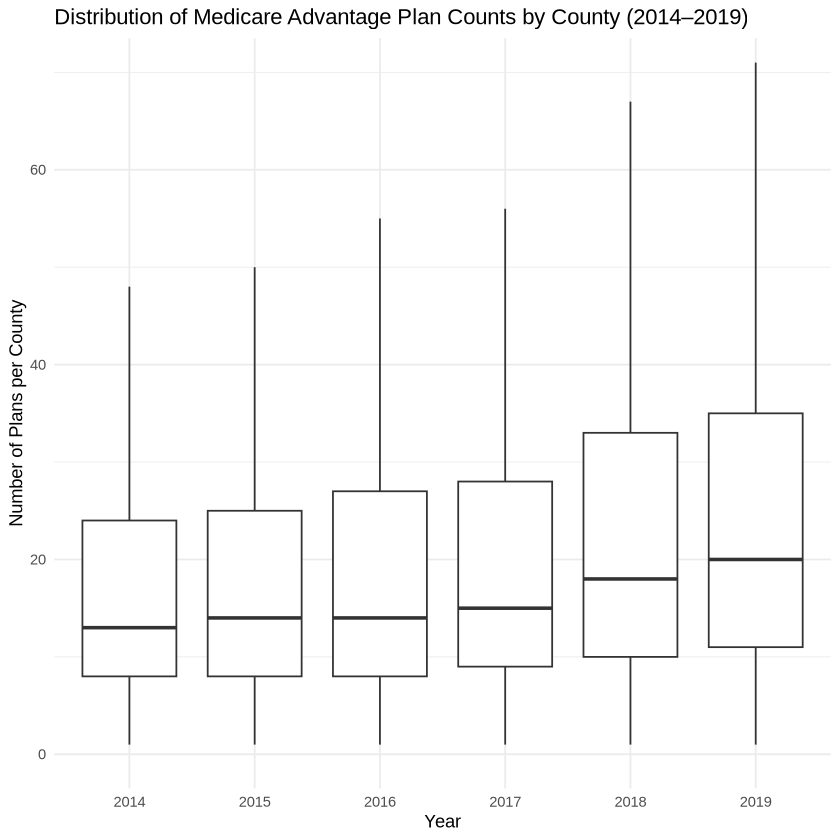

In [7]:
plan_counts <- combined %>%
    group_by(fips, year) %>%
    summarise(plan_count = n())

ggplot(plan_counts, aes(x = factor(year), y = plan_count)) +
 geom_boxplot(outlier.shape = NA) +
 coord_cartesian(ylim = c(0, 70)) +
  labs(
    x = "Year",
    y = "Number of Plans per County",
    title = "Distribution of Medicare Advantage Plan Counts by County (2014–2019)"
  ) +
  theme_minimal()

## Problem 2

After scaling the x and y axis for appropriate comparison of the 2014 and 2018 histogram, a subtle shift of the distribution to fewer plan bids (to the left) can be seen between 2014 to 2018. Additionally, the bid count substantially increased in 2018 compared to 2014, showing a larger number of lower bids being submitted. 

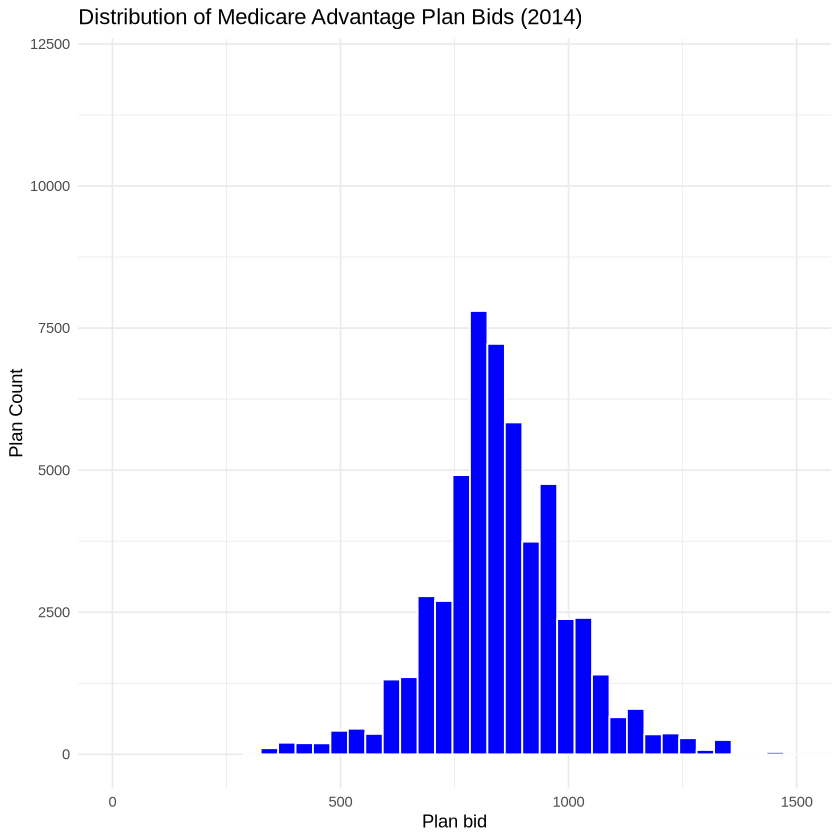

In [8]:
ggplot(filter(combined, year == 2014, !is.na(bid)), aes(x = bid)) +
  geom_histogram(bins = 40, fill = "blue", color = "white") +
  coord_cartesian(xlim = c(0, 1500), ylim = c(0, 12000)) +
  labs(
    title = "Distribution of Medicare Advantage Plan Bids (2014)",
    x = "Plan bid",
    y = "Plan Count"
  ) + 
  theme_minimal()

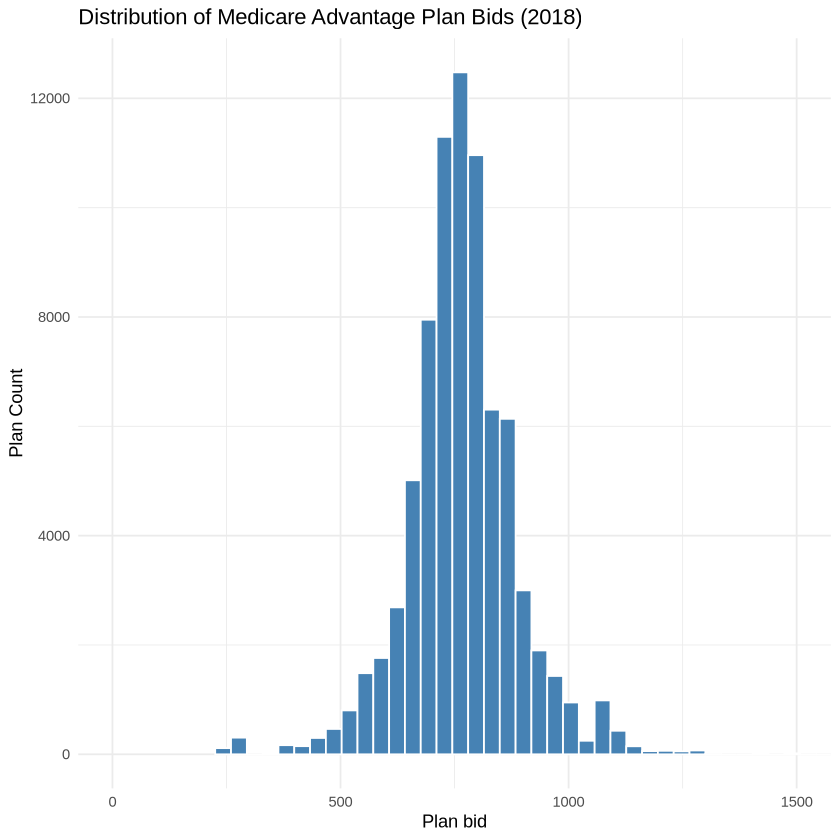

In [9]:
ggplot(filter(combined, year == 2018, !is.na(bid)), aes(x = bid)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  coord_cartesian(xlim = c(0, 1500)) +
  labs(
    title = "Distribution of Medicare Advantage Plan Bids (2018)",
    x = "Plan bid",
    y = "Plan Count"
  ) +
  theme_minimal()

## Problem 3

HHI (0-1 scale used) decreases over time, which shows that the market's competitiveness increased from 2014 to 2019. Typically, since an HHI below 0.15 is considered competitive, the Medicare Advantage market can be seen as going from uncompetitive to competitive at around 2018. 

In [10]:
combined_hhi <- combined %>%
  filter(!is.na(avg_enrolled), avg_enrolled > 0) %>%
  filter(!is.na(avg_enrollment), avg_enrollment > 0) %>%
  group_by(fips, year) %>%
  mutate(market_share = avg_enrollment / avg_enrolled
  ) %>%
  ungroup()


In [11]:
county_hhi <- combined_hhi %>%
  group_by(fips, year) %>%
  summarise(
    hhi = sum(market_share^2),
    .groups = "drop"
  )

In [12]:
avg_hhi <- county_hhi %>%
  group_by(year) %>%
  summarise(
    avg_hhi = mean(hhi),
    .groups = "drop"
  )

avg_hhi

year,avg_hhi
<dbl>,<dbl>
2014,0.1826015
2015,0.1778957
2016,0.1772325
2017,0.1665723
2018,0.1457807
2019,0.1256304


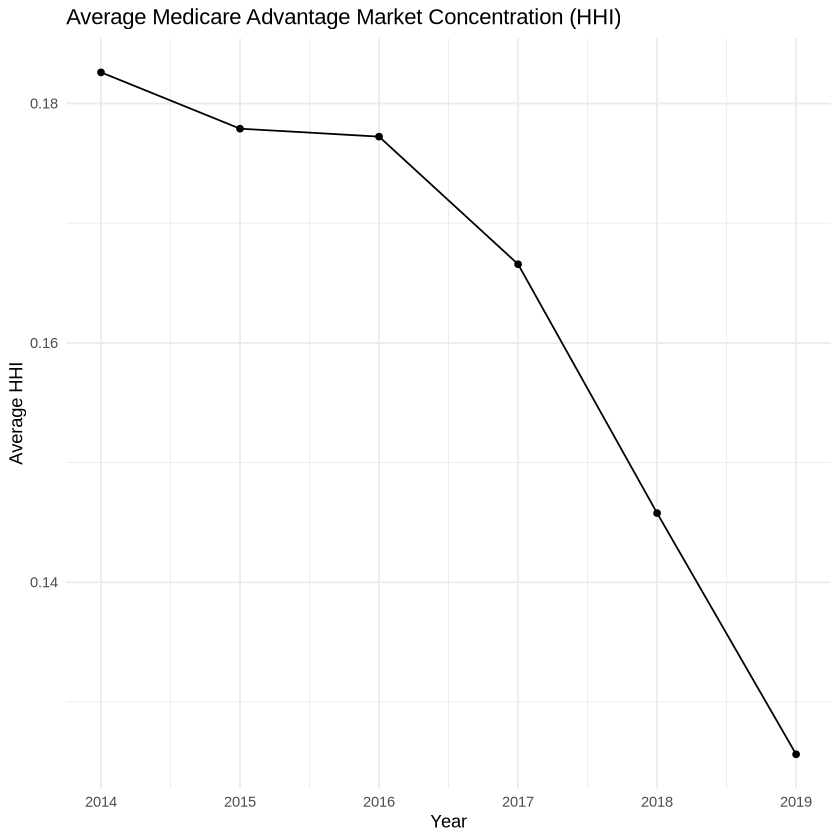

In [13]:
ggplot(avg_hhi, aes(x = year, y = avg_hhi)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Medicare Advantage Market Concentration (HHI)",
    x = "Year",
    y = "Average HHI"
  ) +
  theme_minimal()

## Problem 4

The average share of Medicare Advantage in the market (out of total of 1) over time increases consistently from 2014 to 2019. 

In [14]:
ma_year <- combined %>%
  group_by(year) %>%
    mutate(ma_share = avg_enrolled / avg_eligibles) %>%
    distinct(fips, year, .keep_all = TRUE) %>%
    summarise(
    mean_ma_share = weighted.mean(ma_share, w = avg_eligibles, na.rm = TRUE),
    .groups = "drop"
  )

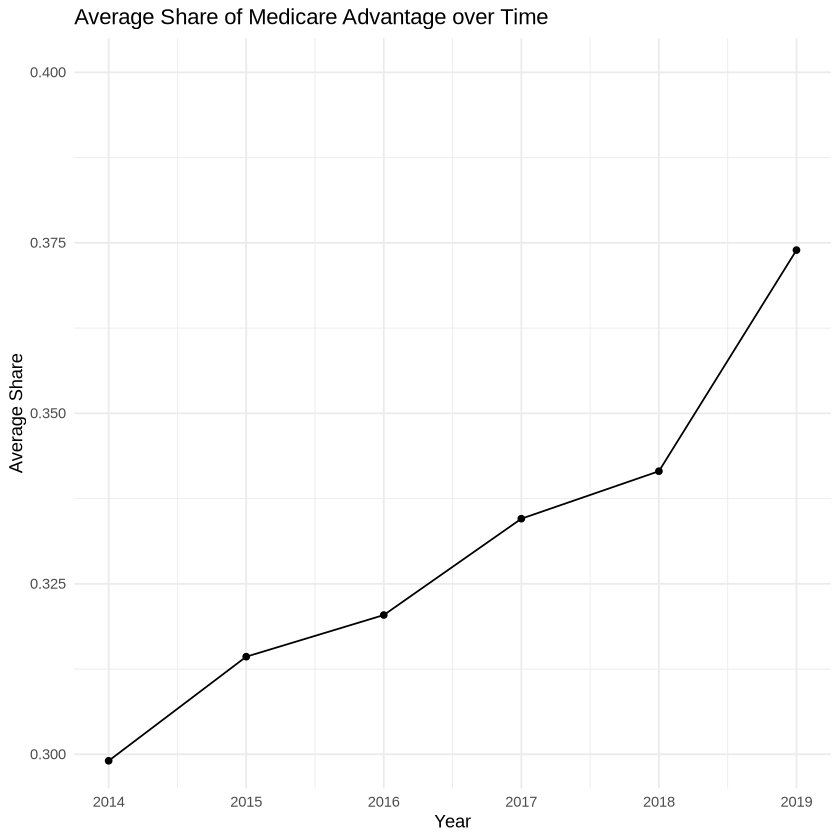

In [15]:
ggplot(ma_year, aes(x = year, y =  mean_ma_share)) +
  geom_line() +
  geom_point() +
  coord_cartesian(ylim = c(0.3, 0.4)) +
  labs(
    title = "Average Share of Medicare Advantage over Time",
    x = "Year",
    y = "Average Share"
  ) +
  theme_minimal()

## Problem 5

In [16]:
marketshare2018 <- data.2018 %>%
  filter(!is.na(avg_enrolled), avg_enrolled > 0) %>%
  filter(!is.na(avg_enrollment), avg_enrollment > 0) %>%
  group_by(fips, year) %>%
  mutate(ma_share = avg_enrollment / avg_enrolled
  ) %>%
  ungroup()

In [17]:
market.data <- marketshare2018 %>%
  group_by(fips) %>%
  summarize(hhi = sum(ma_share^2, na.rm = TRUE),
            bid = mean(bid, na.rm = TRUE),
            avg_ffscost = mean(avg_ffscost, na.rm = TRUE),
           avg_eligibles=mean(avg_eligibles, na.rm=TRUE),
            .groups = "drop")

In [18]:
hhi_33 <- quantile(market.data$hhi, 0.33, na.rm = TRUE)
hhi_66 <- quantile(market.data$hhi, 0.66, na.rm = TRUE)

In [19]:
market.data <- market.data %>%
  mutate(market_type = case_when(
    hhi <= hhi_33 ~ "Competitive",
    hhi >= hhi_66 ~ "Uncompetitive",
    TRUE ~ NA_character_
  ))

In [20]:
avg_bid_by_market <- market.data %>%
  filter(!is.na(market_type), !is.na(bid)) %>%
  group_by(market_type) %>%
  summarise(avg_bid = mean(bid, na.rm = TRUE), n_markets = n(), .groups = "drop")

avg_bid_by_market

market_type,avg_bid,n_markets
<chr>,<dbl>,<int>
Competitive,782.8623,961
Uncompetitive,788.3218,915


In [21]:
avg_bid_by_market %>%
  mutate(avg_bid = round(avg_bid, 5)) %>%
  kable(
    caption = "Average Bid by Market Type (2018)",
    col.names = c("Market type", "Average bid", "N markets"),
    align = c("l", "r", "r")
  ) %>%
  kable_styling(full_width = FALSE, position = "center")

<table class="table" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>Average Bid by Market Type (2018)</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Market type </th>
   <th style="text-align:right;"> Average bid </th>
   <th style="text-align:right;"> N markets </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> Competitive </td>
   <td style="text-align:right;"> 782.8623 </td>
   <td style="text-align:right;"> 961 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> Uncompetitive </td>
   <td style="text-align:right;"> 788.3218 </td>
   <td style="text-align:right;"> 915 </td>
  </tr>
</tbody>
</table>

In [22]:
glimpse(market.data)

Rows: 2,918
Columns: 6
$ fips          <dbl> 1001, 1003, 1005, 1007, 1009, 1011, 1013, 1015, 1017, 10…
$ hhi           <dbl> 0.05923227, 0.10340852, 0.07645623, 0.08586488, 0.091980…
$ bid           <dbl> 723.7879, 727.7726, 766.8556, 708.4215, 723.5019, 725.85…
$ avg_ffscost   <dbl> 8409.298, 8267.190, 9072.908, 9015.985, 8486.866, 7982.5…
$ avg_eligibles <dbl> 11162.333, 52331.000, 6594.500, 5059.000, 12900.833, 216…
$ market_type   <chr> "Competitive", NA, NA, NA, NA, "Competitive", "Uncompeti…


## Problem 6

In [23]:
market.data <- market.data %>%
  mutate(
    treated = case_when(
      market_type == "Uncompetitive" ~ "Treated (high HHI)",
      market_type == "Competitive" ~ "Control (low HHI)",
      TRUE ~ NA_character_
    )
  )

cuts <- quantile(
    market.data$avg_ffscost, 
    probes = c(0, .25, .5, .75, 1), na.rm = TRUE)

market.data$ffs_q <- cut(
    market.data$avg_ffscost,
    breaks = cuts,
    include.lowest = TRUE,
    labels = c("Q1", "Q2", "Q3", "Q4"))

market.data <- market.data %>%
  mutate(
    ffs_q1 = as.integer(ffs_q == "Q1"),
    ffs_q2 = as.integer(ffs_q == "Q2"),
    ffs_q3 = as.integer(ffs_q == "Q3"),
    ffs_q4 = as.integer(ffs_q == "Q4")
  )

In [24]:
market.data %>%
    filter(!is.na(treated), !is.na(ffs_q)) %>%
    group_by(treated, ffs_q) %>%
    summarize(mean.bid = mean (bid, na.rm = TRUE))

`summarise()` has grouped output by 'treated'. You can override using the
`.groups` argument.


treated,ffs_q,mean.bid
<chr>,<fct>,<dbl>
Control (low HHI),Q1,788.8078
Control (low HHI),Q2,784.2709
Control (low HHI),Q3,775.1945
Control (low HHI),Q4,783.9680
Treated (high HHI),Q1,814.5570
Treated (high HHI),Q2,780.4974
Treated (high HHI),Q3,765.6627
Treated (high HHI),Q4,784.8341


In [25]:
avg_bid_wide <- market.data %>%
  filter(!is.na(treated), !is.na(ffs_q), !is.na(bid)) %>%
  group_by(treated, ffs_q) %>%
  summarize(mean_bid = mean(bid, na.rm = TRUE), .groups = "drop") %>%
  mutate(mean_bid = round(mean_bid, 2)) %>%
  pivot_wider(names_from = treated, values_from = mean_bid)

In [26]:
avg_bid_wide %>%
  kable(
    caption = "Mean Bid by FFS Cost Quartile and Treatment Group (2018)",
    col.names = c("FFS quartile", "Control (low HHI)", "Treated (high HHI)"),
    align = c("c", "r", "r")
  ) %>%
  kable_styling(full_width = FALSE, position = "center", bootstrap_options = c("striped"))

<table class="table table-striped" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>Mean Bid by FFS Cost Quartile and Treatment Group (2018)</caption>
 <thead>
  <tr>
   <th style="text-align:center;"> FFS quartile </th>
   <th style="text-align:right;"> Control (low HHI) </th>
   <th style="text-align:right;"> Treated (high HHI) </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:center;"> Q1 </td>
   <td style="text-align:right;"> 788.81 </td>
   <td style="text-align:right;"> 814.56 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> Q2 </td>
   <td style="text-align:right;"> 784.27 </td>
   <td style="text-align:right;"> 780.50 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> Q3 </td>
   <td style="text-align:right;"> 775.19 </td>
   <td style="text-align:right;"> 765.66 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> Q4 </td>
   <td style="text-align:right;"> 783.97 </td>
   <td style="text-align:right;"> 784.83 </td>


## Problem 7

In [27]:
options(repos = c(CRAN = "https://cran.rstudio.com/"))
install.packages("Matching")

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

Warning message in install.packages("Matching"):
“installation of package ‘Matching’ had non-zero exit status”


In [28]:
market.data <- market.data %>%
  filter(
    !is.na(bid),
    !is.na(market_type),
    !is.na(ffs_q),
    !is.na(ffs_q1), !is.na(ffs_q2), !is.na(ffs_q3), !is.na(ffs_q4)
  )

In [143]:
ate_inv <- Matching::Match(Y=market.data$bid,
                Tr=as.integer(market.data$market_type == "Uncompetitive"),
                X= (market.data %>% select(ffs_q1, ffs_q2, ffs_q3, ffs_q4)),
                M=1,
                Weight=1,
                #ties = FALSE,
                version = "fast",
                estimand="ATE")

Increasing memory because of ties: allocating a matrix of size 3 times 375000 doubles.
I would be faster with the ties=FALSE option.


Warning message in MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M, :
“Increasing memory because of ties.  I would be faster with the ties=FALSE option.”


Increasing memory because of ties: allocating a matrix of size 3 times 562500 doubles.
I would be faster with the ties=FALSE option.


Warning message in MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M, :
“Increasing memory because of ties.  I would be faster with the ties=FALSE option.”


In [144]:
ate_inv$est

3.299348


In [145]:
ate_mah <- Matching::Match(Y=market.data$bid,
                          Tr=as.integer(market.data$market_type == "Uncompetitive"),
                          X= (market.data %>% select(ffs_q1, ffs_q2, ffs_q3, ffs_q4)),
                          M=1,
                          Weight=2,
                         # ties = FALSE,
                          version = "fast",
                          estimand="ATE")

Increasing memory because of ties: allocating a matrix of size 3 times 375000 doubles.
I would be faster with the ties=FALSE option.


Warning message in MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M, :
“Increasing memory because of ties.  I would be faster with the ties=FALSE option.”


Increasing memory because of ties: allocating a matrix of size 3 times 562500 doubles.
I would be faster with the ties=FALSE option.


Warning message in MatchLoopCfast(N = s1$N, xvars = Kx, All = s1$All, M = s1$M, :
“Increasing memory because of ties.  I would be faster with the ties=FALSE option.”


In [146]:
ate_mah$est

3.299348


In [147]:
market.data <- market.data %>%
  mutate(treat = as.integer(market_type == "Uncompetitive"))

In [148]:
logit.model <- glm(
  treat ~ ffs_q1 + ffs_q2 + ffs_q3 + ffs_q4,
  family = binomial,
  data = market.data
)

market.data$ps <- fitted(logit.model)

market.data <- market.data %>%
  mutate(ipw = case_when(
    treat == 1 ~ 1 / ps,
    treat == 0 ~ 1 / (1 - ps)
  ))

mean.w1 <- market.data %>%
  filter(treat == 1) %>%
  summarize(mean_y = weighted.mean(bid, ipw, na.rm = TRUE))

mean.w0 <- market.data %>%
  filter(treat == 0) %>%
  summarize(mean_y = weighted.mean(bid, ipw, na.rm = TRUE))

ate_ipw <- mean.w1$mean_y - mean.w0$mean_y

In [149]:
ate_ipw

[1] 3.299348

In [150]:
reg1 <- lm(
  bid ~ ffs_q1 + ffs_q2 + ffs_q3 + ffs_q4,
  data = market.data %>% filter(treat == 1)
)

reg0 <- lm(
  bid ~ ffs_q1 + ffs_q2 + ffs_q3 + ffs_q4,
  data = market.data %>% filter(treat == 0)
)

pred1 <- predict(reg1, newdata = market.data)
pred0 <- predict(reg0, newdata = market.data)

ate_reg <- mean(pred1 - pred0, na.rm = TRUE)
ate_reg

[1] 3.299348

In [151]:
results <- data.frame(
  ate_inv = ate_inv$est,
  ate_mah = ate_mah$est,
  ate_ipw = ate_ipw,
  ate_reg = ate_reg
)

results

ate_inv,ate_mah,ate_ipw,ate_reg
<dbl>,<dbl>,<dbl>,<dbl>
3.299348,3.299348,3.299348,3.299348


In [157]:
ate_tbl <- tibble::tibble(
  Group = "High HHI",
  INV = ate_inv$est,
  MAH = ate_mah$est,
  IPW = ate_ipw,
  OLS = ate_reg
) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

kable(
  ate_tbl,
  format = "latex",
  booktabs = TRUE,
  caption = "ATE Estimates",
  align = "lcccc"
) %>%
  kable_styling(latex_options = c("hold_position"))

\begin{table}[!h]

\caption{ATE Estimates}
\centering
\begin{tabular}[t]{lcccc}
\toprule
Group & INV & MAH & IPW & OLS\\
\midrule
High HHI & 3.299 & 3.299 & 3.299 & 3.299\\
\bottomrule
\end{tabular}
\end{table}

## Problem 8

Nearest neighbor matching with inverse variance distance and with Mahalanobis distance have identical average treatment effect values as well as inverse propensity weighting and simple linear regression. This suggests that the estimated treatment effect is not sensitive to the choice of estimator.

## Problem 9

In [160]:
ate_inv_cont <- Matching::Match(
  Y = market.data$bid,
  Tr = as.integer(market.data$market_type == "Uncompetitive"),
  X = (market.data%>% select(avg_ffscost, avg_eligibles)),
  M = 1,
  Weight = 1,
  version = "fast",
  estimand = "ATE"
)

In [161]:
ate_inv_cont$est

5.131104


In [ ]:
modelsummary(list("INV Baseline"=ate_inv$est, "INV Alternate"=ate_inv_cont$est),
             output="kableExtra") %>%
  kable_styling()

## Problem 10

Working with this data allowed me to see how different estimators will give you identical values but the way that FFS costs are modeled (discrete vs continuous) can affect the average estimated treatment value. One thing that I learned was that it is crucial to know what each name of the row represents so that there is no issue missing a part of the dataset. I was surprised that the bid size between competitive and uncompetitive markets were quite close. 